# synthitaly — demo notebook

What this notebook does, in order:

1. Imports the model and runs it for 30 days with 200 consumers.
2. Shows the first few transactions as a pandas table.
3. Plots how many transactions happen each day (paydays highlighted).
4. Plots the simulated spending mix against the paper baseline.
5. Plots total spending per macro-area (NORTH / CENTRE / SOUTH).
6. Saves the full transaction log to `demo_transactions.csv`.

**To run everything**: click `Run → Run All Cells` in JupyterLab. The whole notebook takes ~5 seconds.

If anything looks confusing, open `docs/HOW_IT_WORKS.md` alongside this notebook.

## 1. Run the simulation

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

from synthitaly import ItalyModel
from synthitaly import numbers

# Build the model. n_consumers and n_days are the only knobs you'll touch
# day-to-day. seed makes the run reproducible.
model = ItalyModel(
    n_consumers=200,
    n_merchants_per_category=10,
    n_days=30,
    seed=42,
)
model.run()

# Turn the in-memory transaction log into a DataFrame.
df = pd.DataFrame(model.transactions)
df["date"] = pd.to_datetime(df["date"])
print(f"Simulated {len(df):,} transactions over {model.n_days} days.")

Simulated 3,798 transactions over 30 days.


## 2. What do the transactions look like?

Every row is something a bank would see on an account.

In [22]:
df.head(10)

,date,kind,from,to,category,amount_eur,macro_area
0,2017-01-01,purchase,453,288,services,25.57,CENTRE
1,2017-01-01,purchase,501,27,retail,39.43,SOUTH
2,2017-01-01,purchase,396,166,home,40.35,CENTRE
3,2017-01-01,purchase,342,8,retail,22.99,NORTH
4,2017-01-01,purchase,474,243,cash_advance,119.70,NORTH
5,2017-01-01,bill,504,307,rent,440.00,NORTH
6,2017-01-01,purchase,471,64,hotels_rest,176.33,NORTH
7,2017-01-01,purchase,467,82,hotels_rest,16.15,SOUTH
8,2017-01-01,bill,450,307,rent,440.00,NORTH
9,2017-01-01,purchase,443,19,retail,18.11,CENTRE


In [23]:
df.groupby("kind")["amount_eur"].agg(["count", "mean", "sum"]).round(2)

,count,mean,sum
kind,,,
bill,409,195.86,80106.39
fee,46,15.24,700.85
loan,23,186.83,4297.00
purchase,3096,43.63,135067.81
salary,224,1692.98,379227.83


## 3. Daily transaction count

A flat line with spikes on the 27th (payday) and the 1st / 5th / 10th / 15th (bill days) is what we expect.

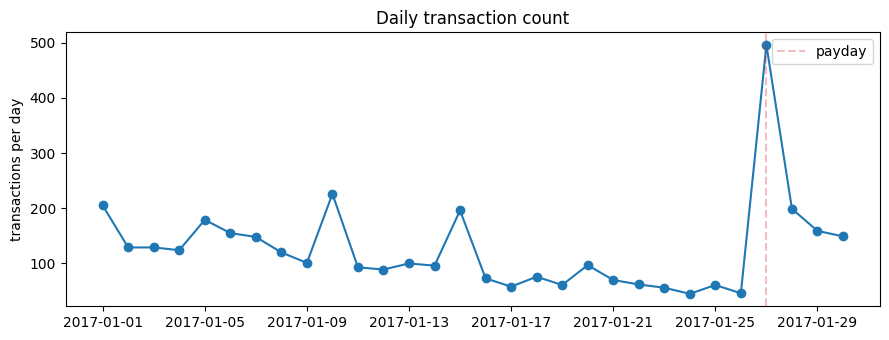

In [24]:
daily = df.groupby("date").size()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(daily.index, daily.values, marker="o", color="tab:blue")
for d in daily.index:
    if d.day == numbers.PAYDAY_DAY_OF_MONTH:
        ax.axvline(d, color="tab:red", alpha=0.3, linestyle="--", label="payday")
# de-duplicate the legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_ylabel("transactions per day")
ax.set_title("Daily transaction count")
fig.tight_layout()
plt.show()

## 4. Spending mix vs. paper baseline

`numbers.CATEGORY_SHARES` are shares of **euros spent** (Emiliozzi et al. 2023, §2.1,
Figures 4 and 6 — Figure 6 compares them against COICOP national-accounts
expenditure). So the comparison below is on euro, not on transaction counts.

The two differ a great deal here, because ticket sizes differ by category: travel
averages ~€100 and phones/web ~€26, so travel takes ~9% of euros from only ~3.4% of
purchases. `numbers.sample_category()` accounts for this by drawing categories with
probability proportional to `share / E[ticket]`, which makes the euro mix match the
paper exactly. Plotting the count mix against these bars would show a model that
appears to miss its own target by 10 percentage points.

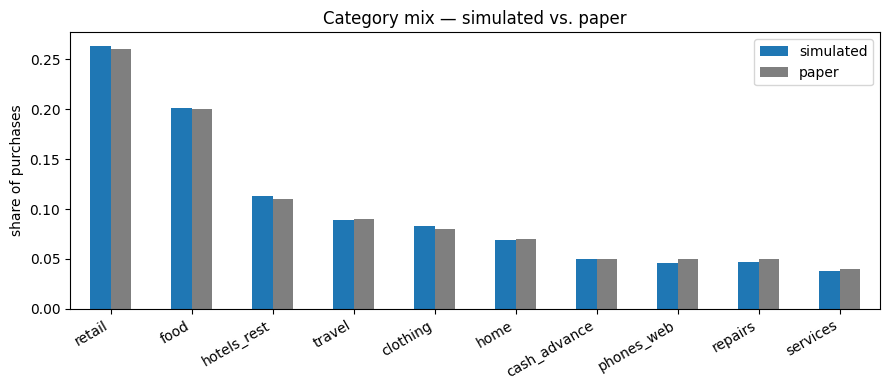

In [25]:
purchases = df[df["kind"] == "purchase"]

# Euro share, to match what CATEGORY_SHARES actually is. The count share is shown
# alongside to make the difference explicit rather than hiding it.
sim_euro = purchases.groupby("category")["amount_eur"].sum()
sim_euro = sim_euro / sim_euro.sum()
sim_count = purchases["category"].value_counts(normalize=True)

paper_share = pd.Series(numbers.CATEGORY_SHARES, name="paper")

compare = pd.DataFrame({
    "simulated (euro)": sim_euro,
    "paper (euro)": paper_share,
    "simulated (count)": sim_count,
}).fillna(0)
compare = compare.sort_values("paper (euro)", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
compare.plot.bar(ax=ax, color=["tab:blue", "tab:gray", "tab:orange"])
ax.set_ylabel("share")
ax.set_title("Category mix — simulated vs. paper (euro shares)")
ax.set_xticklabels(compare.index, rotation=30, ha="right")
fig.tight_layout()
plt.show()

## 5. Spending per macro-area

The simulator assigns consumers to NORTH / CENTRE / SOUTH using the population weights in `numbers.MACRO_AREA_WEIGHTS`. Total spending in each area should follow roughly the same split.

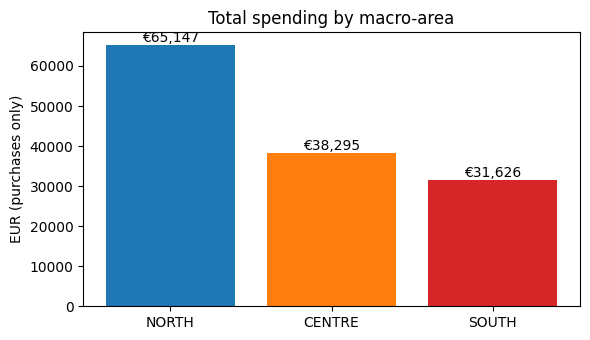

In [26]:
by_area = (
    purchases.groupby("macro_area")["amount_eur"]
    .sum()
    .reindex(["NORTH", "CENTRE", "SOUTH"])
)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["tab:blue", "tab:orange", "tab:red"]
ax.bar(by_area.index, by_area.values, color=colors)
for i, v in enumerate(by_area.values):
    ax.text(i, v, f"€{v:,.0f}", ha="center", va="bottom")
ax.set_ylabel("EUR (purchases only)")
ax.set_title("Total spending by macro-area")
fig.tight_layout()
plt.show()

## 6. Save the full ledger to CSV

Drops a `demo_transactions.csv` next to this notebook. Open it in Excel to inspect every transaction.

In [27]:
out_path = "demo_transactions.csv"
df.to_csv(out_path, index=False)
print(f"Wrote {len(df):,} rows to {out_path!s}")

Wrote 3,798 rows to demo_transactions.csv


## 7. Behavioural-economics layer: payday spike, overdraft & late payment

These behaviours come from the behavioural-finance papers in
`behavioural-economic-papers/` (not the Italian papers): the **payday
spending spike** (Olafsson & Pagel 2018), a **flat overdraft fee** when an
account goes negative (Stango & Zinman 2014), and **late-payment penalties**
when a bill falls due before payday (Dahan & Nisan 2020). Their magnitudes
are modelling choices flagged in `numbers.py`; see
`scripts/sweep_behavioural.py` for the sensitivity sweep.

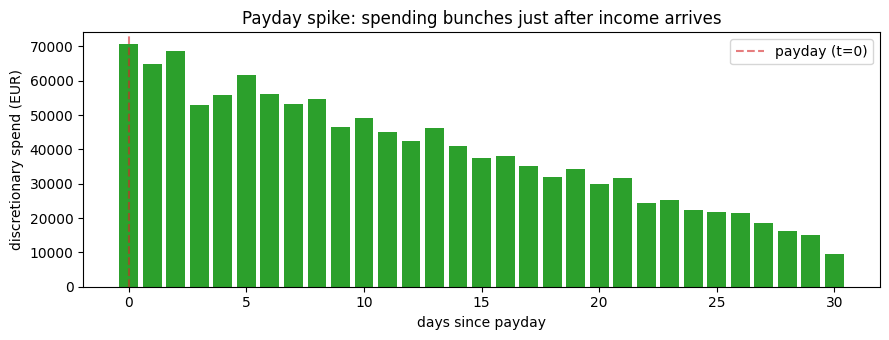

                  count      sum
category                        
late_payment_fee    524  9840.05
overdraft_fee        39  1170.00


In [28]:
# Behavioural-economics layer — run a longer horizon so the new behaviours
# (payday spike, overdraft fees, late payments) have room to appear.
from datetime import date

from synthitaly import ItalyModel, numbers

bmodel = ItalyModel(n_consumers=300, n_merchants_per_category=5, n_days=180, seed=42)
bmodel.run()
bdf = pd.DataFrame(bmodel.transactions)

# (a) Payday spike (Olafsson & Pagel 2018): discretionary spend by day-since-payday.
purch = bdf[bdf["kind"] == "purchase"].copy()


def _days_since_payday(s):
    d = date.fromisoformat(s)
    last, _ = numbers._payday_cycle_bounds(d)
    return (d - last).days


purch["t"] = purch["date"].map(_days_since_payday)
by_t = purch.groupby("t")["amount_eur"].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(by_t.index, by_t.values, color="tab:green")
ax.axvline(0, color="tab:red", linestyle="--", alpha=0.6, label="payday (t=0)")
ax.set_xlabel("days since payday")
ax.set_ylabel("discretionary spend (EUR)")
ax.set_title("Payday spike: spending bunches just after income arrives")
ax.legend()
fig.tight_layout()
plt.show()

# (b) The new account-visible costs: overdraft fees and late-payment fees.
fees = bdf[bdf["kind"] == "fee"]
print(fees.groupby("category")["amount_eur"].agg(["count", "sum"]).round(2))


## 8. Income sources, scale & level

Consumers no longer all earn a flat salary. Each has a primary income
**source** — payroll / self-employed / pension / transfers / **unemployed** —
drawn at its SHIW relative level (payroll 1.08x, self-employed 1.49x, pension
0.82x, transfers 0.50x, unemployed 0.40x of the mean) and with its **own
dispersion** (self-employment widest, pensions/benefits tightest), so the
within-group *scale* differs too. A December thirteenth-month bonus applies to
payroll and pension (wire-transfer paper). Each consumer also gets an absolute
**income level** (low ≤ €1,000 / middle / high > €4,000 per month) from the Bank
of Italy Payment Behaviour Survey bands. Population shares are a flagged
ISTAT-proxy (swept in `scripts/sweep_behavioural.py`).

                      count        sum
category                              
pension                 624  1066352.0
property_income         384    34381.0
salary                 1992  4026309.0
self_employ_income      660  1708882.0
transfers               132   103023.0
unemployment_benefit    192   128090.0


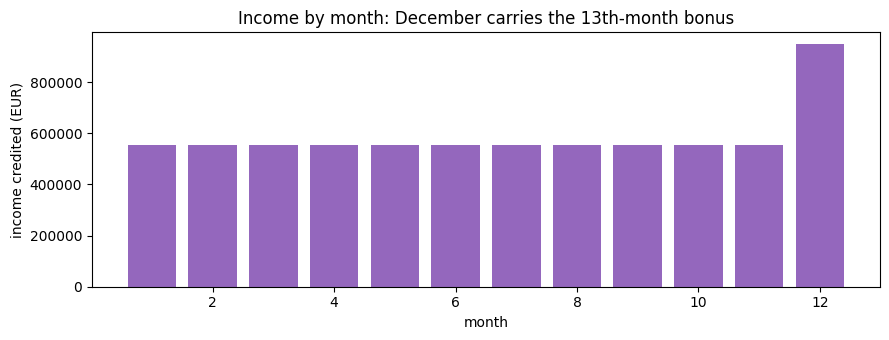

In [29]:
# Income sources need a long horizon to reach December.
imodel = ItalyModel(n_consumers=300, n_merchants_per_category=5, n_days=365, seed=42)
imodel.run()
idf = pd.DataFrame(imodel.transactions)
idf["date"] = pd.to_datetime(idf["date"])

# (a) Income credited by source category (kind == "salary").
income = idf[idf["kind"] == "salary"]
print(income.groupby("category")["amount_eur"].agg(["count", "sum"]).round(0))

# (b) Total income per month — the December tredicesima shows as a spike.
by_month = income.groupby(income["date"].dt.month)["amount_eur"].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(by_month.index, by_month.values, color="tab:purple")
ax.set_xlabel("month")
ax.set_ylabel("income credited (EUR)")
ax.set_title("Income by month: December carries the 13th-month bonus")
fig.tight_layout()
plt.show()


## 9. Chronically-indebted households: stuck by construction

The debtor archetypes (climber / chronic / subsister) split the SHIW-flagged
debtors, **tilted by SHIW 2022 §3 financial vulnerability** (income below median
*and* debt-service ratio > 30%): vulnerable debtors are drawn chronic-heavy,
resilient ones climber-heavy. The check below confirms the chronic mechanic
"works really well": a chronic debtor pays **at most the interest**, so the
principal is **non-decreasing — it never falls and never clears**, held flat when
they can cover the interest and creeping up when they're too cash-poor to. **No
chronic debtor digs out**, and the cohort concentrates among the financially
vulnerable — while climbers' principal falls all the way to zero.

            n  dug_out  vulnerable  mean_opening_eur  mean_final_eur
subtype                                                             
climber    46       38           1              5394             347
chronic    14        0           9              6456            6726
subsister  15        0           3              8744           10182

OK — chronic never clears (mean principal +4.2% over 24 months, held by interest-only payments), none dug out; 9/14 chronic are financially vulnerable.


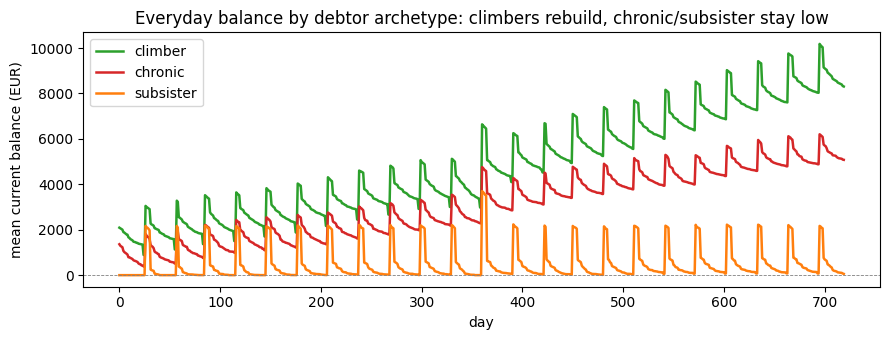

In [30]:
# Long horizon so climbers have time to dig out and the chronic line can be
# seen holding (interest-only) rather than clearing.
import numpy as np

cmodel = ItalyModel(n_consumers=400, n_merchants_per_category=5, n_days=720, seed=42)
cmodel.run()

# Per-archetype summary: count, how many dug out, mean opening vs final principal.
rows = []
for st in numbers.DEBTOR_SUBTYPES:
    grp = [c for c in cmodel.consumers if c.debtor_subtype == st]
    if not grp:
        continue
    opening = np.mean([c._debt_history[0] for c in grp if c._debt_history])
    final = np.mean([c.debt_balance for c in grp])
    rows.append({
        "subtype": st,
        "n": len(grp),
        "dug_out": sum(1 for c in grp if not c.has_debt),
        "vulnerable": sum(1 for c in grp if c.is_financially_vulnerable),
        "mean_opening_eur": round(opening),
        "mean_final_eur": round(final),
    })
summary = pd.DataFrame(rows).set_index("subtype")
print(summary)

# Verification of the chronic mechanic:
#   • a chronic debtor pays at most the interest → principal NON-DECREASING
#     (every chronic debtor's final balance >= its opening), so it never clears;
#   • NONE dig out; while climbers DO pay down to zero and leave debt.
chronic = [c for c in cmodel.consumers if c.debtor_subtype == "chronic"]
assert all(c.debt_balance >= c._debt_history[0] - 1e-6 for c in chronic if c._debt_history), \
    "a chronic principal fell — should be interest-only (non-decreasing)"
assert summary.loc["chronic", "dug_out"] == 0, "a chronic debtor dug out — mechanic broken!"
assert summary.loc["climber", "dug_out"] > 0, "no climber dug out over 720 days"
drift = (summary.loc["chronic", "mean_final_eur"] / summary.loc["chronic", "mean_opening_eur"]) - 1
print(
    f"\nOK — chronic never clears (mean principal {drift:+.1%} over 24 months, "
    f"held by interest-only payments), none dug out; "
    f"{summary.loc['chronic', 'vulnerable']}/{len(chronic)} chronic are financially vulnerable."
)

# Mean current-account balance over time, by archetype (the contrast view).
cdf = cmodel.datacollector.get_model_vars_dataframe()
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = {"climber": "tab:green", "chronic": "tab:red", "subsister": "tab:orange"}
for st in numbers.DEBTOR_SUBTYPES:
    ax.plot(cdf.index, cdf[f"bal_cur_dst_{st}"], color=colors[st], lw=1.8, label=st)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xlabel("day")
ax.set_ylabel("mean current balance (EUR)")
ax.set_title("Everyday balance by debtor archetype: climbers rebuild, chronic/subsister stay low")
ax.legend()
fig.tight_layout()
plt.show()
